# Setup

In [75]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [76]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

from VirtualSAS_theory import VirtualSAS_theory

from AFL.double_agent import *
from AFL.double_agent.PyTorchExtrapolator import DirichletGPExtrapolator 

from tqdm.auto import tqdm 
from typing import Optional, Union, List, Tuple, Dict, Any

## Load Boundary Dataset

In [77]:
boundary_dataset = xr.load_dataset('250610-extrap_expand_dataset.nc')
boundary_dataset

<xarray.Dataset> Size: 500kB
Dimensions:      (component: 3, sample: 15625)
Coordinates:
  * component    (component) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    composition  (component, sample) float64 375kB -3.507 -3.507 ... 9.008 9.558
    labels       (sample) int64 125kB 0 0 0 0 0 0 0 0 0 0 ... 2 2 2 2 2 2 2 2 2
Attributes:
    labels:          labels
    components:      composition
    components_dim:  component

In [78]:
boundary_dataset.close()

## Instantiate Instrument and Draw Boundaries

In [79]:
from AFL.automation.APIServer.data.DataTrashcan import DataTrashcan

reference_data_path = './SANS/'
inst_client = VirtualSAS_theory()
inst_client.data = DataTrashcan()
boundary_dataset['labels'] = boundary_dataset.labels.astype(str)
inst_client.boundary_dataset = boundary_dataset
inst_client.trace_boundaries(hull_tracing_ratio=0.25)


## Add sasmodels

In [80]:
# specify reference data
for fname in ['low_q.ABS', 'med_q.ABS', 'high_q.ABS']:
    data = pd.read_csv(str(pathlib.Path(reference_data_path) / fname),sep=r'\s+')#, delim_whitespace=True)
    inst_client.add_configuration(
        q=list(data.q),
        I=list(data.I),
        dI=list(data.dI),
        dq=list(data.dq),
        reset=False
    )

inst_client.add_sasview_model(
    label='2',
    model_name='polymer_excl_volume',
    model_kw={
        'scale': 1.0,
        'background': 1.0,
        'rg': 100.0,
    }
)

inst_client.add_sasview_model(
    label='1',
    model_name='sphere',
    model_kw={
        'scale': 0.5,
        'background': 1.0,
        'sld': 1.0,
        'sld_solvent': 6.0,
        'radius': 10,
    }
)

inst_client.add_sasview_model(
    label='0',
    model_name='power_law',
    model_kw={
        'scale': 1e-7,
        'background': 1.0,
        'power': 4.0,
    }
)
inst_client

## Test Virtual Instrument

In [109]:
ds_list = []
for temp in [0,10,20,30,40,50]:
    ds = inst_client.simple_expose({'protein':40,'temperature':temp,'glycerol':5})
    ds['phases'] = int(ds.attrs['labels'])
    ds_list.append(ds)

ds = xr.concat(ds_list,dim='sample')
ds

<xarray.Dataset> Size: 43kB
Dimensions:      (sample: 6, q: 281, component: 3)
Coordinates:
  * q            (q) float64 2kB 0.003836 0.004348 0.004859 ... 0.6293 0.6334
  * component    (component) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    I            (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    I_noiseless  (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    dI           (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    composition  (sample, component) int64 144B 40 0 5 40 10 5 ... 40 5 40 50 5
    phases       (sample) int64 48B 2 1 1 1 0 0
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

# Virtual Active Learning

## Initial Dataset

In [110]:
ds_list = []
for temp in [0,10,20,30,40,50]:
    ds = inst_client.simple_expose({'protein':40,'temperature':temp,'glycerol':5})
    ds_list.append(ds)

ds_init = xr.concat(ds_list, dim='sample')
ds_init

<xarray.Dataset> Size: 43kB
Dimensions:      (sample: 6, q: 281, component: 3)
Coordinates:
  * q            (q) float64 2kB 0.003836 0.004348 0.004859 ... 0.6293 0.6334
  * component    (component) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    I            (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    I_noiseless  (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    dI           (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    composition  (sample, component) int64 144B 40 0 5 40 10 5 ... 40 5 40 50 5
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

### Construct a cost model for the design space 

We are interested in querying a design space $\mathcal{X}$, to find an underlying function $f(x)$ that labels any given point $x \in \mathcal{X}$. Our design sampling criteria is defined by a Gaussian Process model that takes the discrete label outputs of $f(x) = y \in \{0,1,2,3...,d\}$ and turns them into probabilities over each label $p(y = d | x)$. 

In traditional active learning setting with the above mathematical setup assuming the cost to evaluate points across different components of $\mathcal{X}$ to be the same, we would devise a sampling strategy based on entropy of the probabilistic outputs of the GP. A typical stragety is to sample points in $\mathcal{X}$ that have the maximum entropy--leading to a decision closer to the percieved boundary. 

In presence of an associated, heterogenous cost to each `dimension` of $\mathcal{X}$, we can use cost per unit approach originally presented [here](https://papers.nips.cc/paper_files/paper/2012/hash/05311655a15b75fab86956663e1819cd-Abstract.html), that simply scales the acquisition criteria by the cost per each sample. Using this formalism, we get:
$$ \mathrm{Entropy}_{\mathrm{pu}} := \frac{\mathrm{Entropy}(x)}{C(x)} $$

This serves as a baseline approach where we can pre-specify a cost function and use it to bias our design sampling to be effective to certain costs or penalties inherent to sampling the design space. This also requires only single change to the exisiting pipeline that computes the acquisition cost per unit or sample which is then passed onto a active learning selector.

In [83]:
import sympy

T, dT = sympy.symbols('T dT')

# Constants
alpha_h = 0.05
alpha_c = 0.45
tow_s = 0.25
beta = 0.25
T_thresh = 40.0
T_scale = 5.0


# Component 2: Heating cost (only when T > T_base)
C_heat = alpha_h * sympy.Piecewise((0, dT <= 0), (dT, dT > 0))

# Component 3: Cooling cost (only when T < T_base)
C_cool = alpha_c * sympy.Piecewise((0, dT >= 0), (-dT, dT < 0))

# Component 4: Degradation cost (only when T > T_thresh)
C_deg = beta * sympy.Piecewise(
    (0, T <= T_thresh),
    ((T - T_thresh) / T_scale, T > T_thresh)
)

In [84]:
C_heat

0.05*Piecewise((0, dT <= 0), (dT, True))

In [85]:
C_cool

0.45*Piecewise((0, dT >= 0), (-dT, True))

In [86]:
C_deg

0.25*Piecewise((0, T <= 40.0), (0.2*T - 8.0, True))

In [87]:
def minmax_normalize(arr: np.ndarray,
                    axis: Optional[Union[int, Tuple[int, ...]]] = None,
                    eps: float = 1e-8
                ) -> np.ndarray:
    """
    Min-max normalize a NumPy array along a given axis or globally.

    Parameters:
    -----------
    arr : np.ndarray
        Input array (1D or multi-dimensional).
    axis : Optional[int or Tuple[int, ...]]
        Axis or axes along which to normalize. If None, normalize globally.
    eps : float
        Small epsilon to avoid division by zero.

    Returns:
    --------
    normalized : np.ndarray
        Normalized array with same shape as input, scaled to [0, 1].
    """
    arr = np.asarray(arr)
    min_val = np.min(arr, axis=axis, keepdims=True)
    max_val = np.max(arr, axis=axis, keepdims=True)
    normalized = (arr - min_val) / (max_val - min_val + eps)
    return normalized

In [88]:
# PipelineOp for cost-aware acquisition 
class CompositionTemperatureActionCost(PipelineOp):
    """A post-processing `PipelineOp` that computes cost of evaluating a data point.

    Parameters
    ----------
    input_variable : str
        The name of the `xarray.Dataset` data variable to extract from the input dataset
    grid_variable: str
        The name of the `xarray.Dataset` data variable to use as a evaluation grid.
    grid_dim: str
        The name of the `xarray.Dataset` data variable to use as a evaluation grid.
    grid_variable: str
        The name of the `xarray.Dataset` data variable to use as a evaluation grid.
    grid_variable: str
        The name of the `xarray.Dataset` data variable to use as a evaluation grid.        
    output_variable : str
        The name of the variable to be inserted into the `xarray.Dataset` by this `PipelineOp`
    name : str
        The name to use when added to a Pipeline. This name is used when calling Pipeline.search()
    """

    def __init__(
        self,
        input_variable: str = None,
        sample_dim: str = None,
        grid_variable: str = None,
        grid_dim: str = "grid",
        composition_variable: Optional[List[str]] = None,
        temperature_variable: str=None,
        output_variable: str = None,
        name: str = "CompositionTemperatureActionCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[input_variable, grid_variable], output_variable=output_variable
        )
        self.sample_dim = sample_dim
        self.grid_variable = grid_variable
        self.grid_dim = grid_dim
        self.composition_variable = composition_variable
        self.temperature_variable = temperature_variable

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Compute and store normalized cost over the full grid."""
        data = dataset[self.input_variable]
        grid = dataset[self.grid_variable]

        cost_grid = self.evaluate_cost(query=grid, sampled=data)

        norm_cost_grid = minmax_normalize(cost_grid, axis=0).sum(axis=1)
        self.output[self.output_variable] = xr.DataArray(norm_cost_grid, dims=self.grid_dim)
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Cost per sample (normalized) evaluated on {self.grid_variable}"

        return self
    
    def evaluate_cost(self,
                      query: xr.DataArray,
                      sampled: xr.DataArray
                    ) -> np.ndarray:
        """Compute cost for each query point using previously sampled data."""
        t_sampled, c_sampled = self._extract_components(sampled)
        t_query, c_query = self._extract_components(query)

        sampled_values = sampled.values
        cost_array = np.zeros((query.shape[0], 3))

        for i in range(query.shape[0]):
            q_point = query.values[i]

            if self._is_in_sampled(sampled_values, q_point):
                cost = np.ones(3) * 1e-3
            elif self._composition_in_sampled(c_sampled, c_query[i]):
                cost = self._partial_cost(c_sampled, t_sampled, c_query[i], t_query[i])
            else:
                cost = self._full_cost(c_query[i], t_query[i])

            cost_array[i, :] = cost

        return cost_array

    def _extract_components(self, 
                            array: xr.DataArray
                        ) -> tuple[np.ndarray, np.ndarray]:
        """Split temperature and composition components."""
        t = array.sel(component=self.temperature_variable).values
        c = np.array([
            array.sel(component=comp).values for comp in self.composition_variable
        ]).T
        return t, c

    def _is_in_sampled(self, 
                       sampled_values: np.ndarray, 
                       point: np.ndarray
                    ) -> np.bool:
        return np.any(np.all(point == sampled_values, axis=1))

    def _composition_in_sampled(self, 
                                c_sampled: np.ndarray, 
                                c_point: np.ndarray
                            ) -> np.bool:
        return np.any(np.all(c_sampled == c_point, axis=1))

    def _partial_cost(self,
                      c_sampled: np.ndarray,
                      t_sampled: np.ndarray,
                      c_point: np.ndarray,
                      t_point: float
                    ) -> np.ndarray:
        flags = np.all(c_sampled == c_point, axis=1)
        if flags.sum() > 1:
            indx = ((t_sampled - t_point) ** 2).argmin()
        else:
            indx = np.argwhere(flags).squeeze()

        delta_t = (t_point - t_sampled[indx]).squeeze()
        return np.array([
            0.0,
            self._temperature_cost(delta_t),
            self._degradation_cost(t_point)
        ])

    def _full_cost(self, 
                   c_point: np.ndarray, 
                   t_point: float
                ) -> np.ndarray:
        delta_t = (t_point - 27.0)
        return np.array([
            sum(c_point),
            self._temperature_cost(delta_t),
            self._degradation_cost(t_point)
        ])

    def _temperature_cost(self, delta_t: float) -> float:
        return -delta_t * 50.0 if delta_t < 0 else delta_t * 25.0

    def _degradation_cost(self, t: float) -> float:
        return 10.0 * ((t - 40.0) / 5.0) if t > 40.0 else 0.0

### Modeling hierarchical costs in different design variables

In [89]:
class DesignSpaceHierarchyCost(PipelineOp):
    def __init__(
        self,
        grid_variable: str = None,
        grid_dim:str =None,
        variables_order : List[str] = None,
        variables_offsets : List[float] = None,
        output_variable: str = None,
        name: str = "DesignSpaceHierarchyCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[grid_variable], output_variable=output_variable
        )
        self.variables_order = variables_order
        self.variables_offsets = variables_offsets
        self.grid_variable = grid_variable
        self.grid_dim = grid_dim
        self.iteration = 1

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Compute and store normalized cost over the full grid."""
        grid = dataset[self.grid_variable]

        cost_grid = self.evaluate_cost(query=grid)

        self.output[self.output_variable] = xr.DataArray(cost_grid, dims=self.grid_dim)
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Cost per sample evaluated on {self.input_variable}"

        return self
    
    def evaluate_cost(self,
                      query: xr.DataArray,
                    ) -> np.ndarray:
        """Compute cost for each query point using previously sampled data."""
        num_queries = query.shape[0]
        k = query.shape[1]
        output = np.zeros(num_queries)
        for i in range(num_queries):
            w = np.sort(np.random.dirichlet(np.ones(k),size=1))[0]
            dim_cost = []
            for j in range(k):
                ell = 1/((w[j]*self.iteration)+1)
                x = query.sel(component=self.variables_order[j]).values[i]
                f_x_t = ell*np.exp(-(np.abs(x-self.variables_offsets[j])*ell))
                dim_cost.append(1-f_x_t)
            output[i] = np.prod(np.array(dim_cost))

        self.iteration += 1
        return output

### Modeling unknown feasibility constraints

In [90]:
class FeasibilityLabeler(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        output_variable: str = None,
        dim: str = "sample",
        name: str = "FeasibilityLabeler",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=input_variable, 
            output_variable=output_variable,
        )
        self.dim = dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Label samples as feasible or infeasible based on cost."""
        data = dataset[self.input_variable]
        cost = data.sel(component='temperature').values
        labels = np.where(cost > 0.75, 0, 1)  # 0 for feasible, 1 for infeasible
        self.output[self.output_variable] = xr.DataArray(labels, dims=[self.dim])
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Feasibility labels based on {self.input_variable}"

        return self

### Create cost-aware acquisition function

In [91]:
class AcquisitionWithCost(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        cost_variables: List[str] = None,
        grid_dim: str = "grid",
        output_variable: str = None,
        name: str = "AcquisitonPerUnitCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[input_variable] + cost_variables, output_variable=output_variable
        )
        self.cost_variables = cost_variables
        self.grid_dim = grid_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Apply this `PipelineOp` to the supplied `xarray.Dataset` using xarray operations only."""

        acqv = dataset[self.input_variable]

        # Compute acquisition per unit cost
        # Q(x,t)/C(x,t)

        # acqv_cost = acqv / (cost + 1e-9)
        # norm_acqv_cost = minmax_normalize(acqv_cost)

        # Add acquisition and acquiring cost Q(x,t) + C(x,t)
        # This reduces the absurd case of sampling existing points that have zero cost
        # this maximizes the acquisition per unit cost
        # we are however assuming that acquisition and cost are measured in the same units.

        # norm_acqv_cost = minmax_normalize(acqv.values) - minmax_normalize(cost.values)

        # Anther option is to Q(x, t)*(1-C(x,t)) following 
        # https://arxiv.org/pdf/1909.03600 Equation 9 
        acqv_cost = acqv.values.copy()
        for var in self.cost_variables:
            cost = dataset[var].values
            acqv_cost *= (1.0-cost)

        # Normalize
        output = xr.DataArray(acqv_cost, dims=self.grid_dim)

        # Store result
        self.output[self.output_variable] = output
        self.output[self.output_variable].attrs["description"] = "Acquisition with Cost (Normalized)"

        return self


### Creatte the pipeline for active learning

In [92]:
with Pipeline(name = "find_boundaries") as p:
    CartesianGrid(
        output_variable="composition_grid",
        sample_dim="grid",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 25},
                     'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 25},
                     'temperature':{'min': 0.0, 'max': 50.0, 'steps': 25}}
    )

    Standardize(
        input_variable="composition",
        output_variable="normalized_composition",
        dim="sample",
        component_dim="component",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )

    Standardize(
        input_variable="composition_grid",
        output_variable="normalized_composition_grid",
        dim="grid",
        component_dim="component",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )

    SavgolFilter(
        input_variable="I",
        output_variable="derivative0",
        dim="q",
        xlo=None,
        xhi=None,
        xlo_isel=None,
        xhi_isel=None,
        pedestal=None,
        npts=250,
        derivative=0,
        window_length=31,
        polyorder=2,
        apply_log_scale=True,
        name="SavgolFilter",
    )

    SavgolFilter(
        input_variable="I",
        output_variable="derivative1",
        dim="q",
        xlo=None,
        xhi=None,
        xlo_isel=None,
        xhi_isel=None,
        pedestal=None,
        npts=250,
        derivative=1,
        window_length=31,
        polyorder=2,
        apply_log_scale=True,
        name="SavgolFilter",
    )

    Similarity(
        input_variable="derivative0",
        output_variable="similarity0",
        sample_dim="sample",
        params={'metric': 'laplacian', 'gamma': 0.0025},
        constrain_same=[],
        constrain_different=[],
        name="SimilarityMetric",
    )

    Similarity(
        input_variable="derivative1",
        output_variable="similarity1",
        sample_dim="sample",
        params={'metric': 'laplacian', 'gamma': 0.0025},
        constrain_same=[],
        constrain_different=[],
        name="SimilarityMetric",
    )

    CombineMetric(
        input_variables=['similarity0','similarity1'],
        output_variable="similarity",
        sample_dim="sample",
        combine_by="sum",
        combine_by_powers=None,
        combine_by_coeffs=None,
        name="CombineMetric",
    )

    SpectralClustering(
        input_variable="similarity",
        output_variable="labels",
        dim="sample",
        params={'n_phases': 3},
        name="SpectralClustering",
        use_silhouette=False,
    )
    
    DirichletGPExtrapolator(
        feature_input_variable="normalized_composition",
        predictor_input_variable="labels",
        output_prefix="phase",
        grid_variable="normalized_composition_grid",
        grid_dim="grid",
        sample_dim="sample",
        params={"learning_rate": 1e-1, "n_iterations": 100, "verbose": False},
        name="DirichletGPExtrapolator-PhaseLabels",
    )
    DesignSpaceHierarchyCost(
        grid_variable="normalized_composition_grid",
        grid_dim="grid",
        variables_order=['temperature','protein', 'glycerol'],
        variables_offsets=[0.5, 0.0, 0.0],
        output_variable="hierarchy_cost",
        name="CompositionTemperatureHierarchyCost",
    )
    FeasibilityLabeler(
        input_variable="normalized_composition",
        output_variable="feasibility_labels",
        dim="sample",
        name="FeasibilityLabeler",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_composition",
        predictor_input_variable="feasibility_labels",
        output_prefix="feasibility",
        grid_variable="normalized_composition_grid",
        grid_dim="grid",
        sample_dim="sample",
        params={"learning_rate": 1e-1, "n_iterations": 100, "verbose": False},
        name="DirichletGPExtrapolator-FeasibilityLabels",
    )    
    AcquisitionWithCost(
        input_variable="phase_entropy",
        cost_variables=["hierarchy_cost", "feasibility_y_prob"],
        grid_dim="grid",        
        output_variable="acqv_cost",
        name="AcquisitionWithCost",
    )
    MaxValueAF(
        input_variables=['acqv_cost'],
        grid_variable="composition_grid",
        grid_dim="grid",
        combine_coeffs=None,
        output_prefix=None,
        output_variable="next_sample",
        decision_rtol=0.05,
        excluded_comps_variables=None,
        excluded_comps_dim=None,
        exclusion_radius=0.001,
        count=1,
        name="MaxValueAF",
    )

p.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> composition_grid
1  ) <Standardize>                       composition ---> normalized_composition
2  ) <Standardize>                       composition_grid ---> normalized_composition_grid
3  ) <SavgolFilter>                      I ---> derivative0
4  ) <SavgolFilter>                      I ---> derivative1
5  ) <SimilarityMetric>                  derivative0 ---> similarity0
6  ) <SimilarityMetric>                  derivative1 ---> similarity1
7  ) <CombineMetric>                     ['similarity0', 'similarity1'] ---> similarity
8  ) <SpectralClustering>                similarity ---> labels
9  ) <DirichletGPExtrapolator-PhaseLabels> ['normalized_composition', 'labels', 'normalized_composition_grid'] ---> ['phase_y_prob']
10 ) <CompositionTemperatureHierarchyCost> 

In [93]:
def plot_value_slices(ds, value_name):
    composition_grid = ds.composition_grid.values
    values = ds[value_name].values

    fig, axs = plt.subplots(2,3, figsize=(4*3, 4*2))
    fig.subplots_adjust(wspace=0.3, hspace=0.3)
    axs = axs.flatten()
    norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
    cmap = plt.get_cmap('coolwarm') 
    mappable = ScalarMappable(norm=norm, cmap=cmap)

    for i, value in enumerate(np.arange(0, 51, 10)):
        flags = np.isclose(composition_grid[:,1], value, atol=1.0)
        ax = axs[i]
        ax.tricontourf(composition_grid[flags,0],
                    composition_grid[flags,2],
                    values[flags],
                    cmap = cmap,
                    norm = norm
                    )
        ax.set_xlabel("Protein")
        ax.set_title("Temperature = %d"%value)
        ax.set_ylabel("Glycerol")
    cax = fig.add_axes([0.95, 0.3, 0.02, 0.4])  # [left, bottom, width, height]
    cbar = fig.colorbar(mappable, shrink=0.5, aspect=5, cax=cax)
    plt.show()

### Test Pipeline

In [94]:
ds_result = p.calculate(ds_init)
ds_result

  0%|          | 0/15 [00:00<?, ?it/s]

<xarray.Dataset> Size: 2MB
Dimensions:                      (q: 281, component: 3, sample: 6, grid: 15625,
                                  log_q: 250, sample_i: 6, sample_j: 6,
                                  AF_sample: 1)
Coordinates:
  * q                            (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * component                    (component) object 24B 'protein' ... 'glycerol'
  * log_q                        (log_q) float64 2kB -2.416 -2.407 ... -0.1983
Dimensions without coordinates: sample, grid, sample_i, sample_j, AF_sample
Data variables: (12/24)
    I                            (sample, q) float64 13kB 1.95 1.937 ... 1.0 1.0
    I_noiseless                  (sample, q) float64 13kB 1.95 1.937 ... 1.0 1.0
    dI                           (sample, q) float64 13kB 0.0 0.0 ... 0.0 0.0
    composition                  (sample, component) int64 144B 40 0 5 ... 50 5
    composition_grid             (grid, component) float64 375kB 0.0 ... 12.0
    normalized_composition       (sample, component) float64 144B 0.5 ... 0.4167
    ...                           ...
    feasibility_mean             (grid) int64 125kB 1 1 1 1 1 1 ... 1 1 1 1 1 1
    feasibility_entropy          (grid) float64 125kB 0.5932 0.5973 ... 0.6057
    feasibility_y_prob           (grid) float64 125kB 0.5932 0.5973 ... 0.6057
    acqv_cost                    (grid) float64 125kB 0.3563 0.356 ... 0.2997
    decision_surface             (grid) float64 125kB 0.2312 0.2307 ... 0.1158
    next_sample                  (AF_sample, component) float64 24B 36.67 ......
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

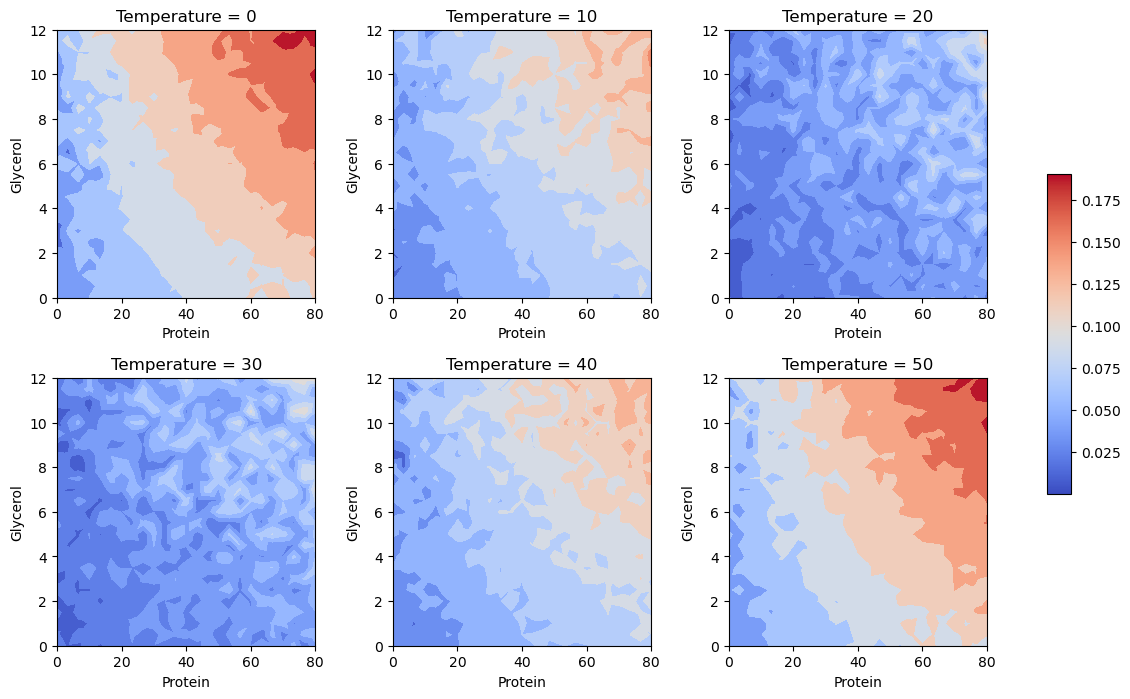

In [95]:
plot_value_slices(ds_result, "hierarchy_cost")

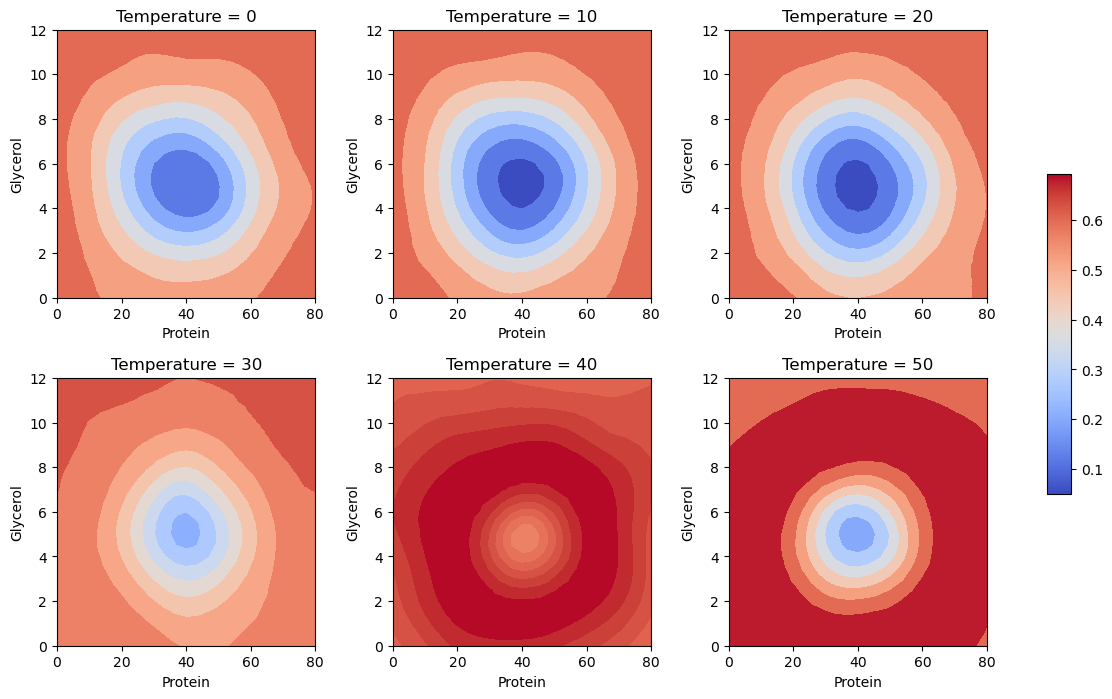

In [96]:
plot_value_slices(ds_result, "feasibility_y_prob")

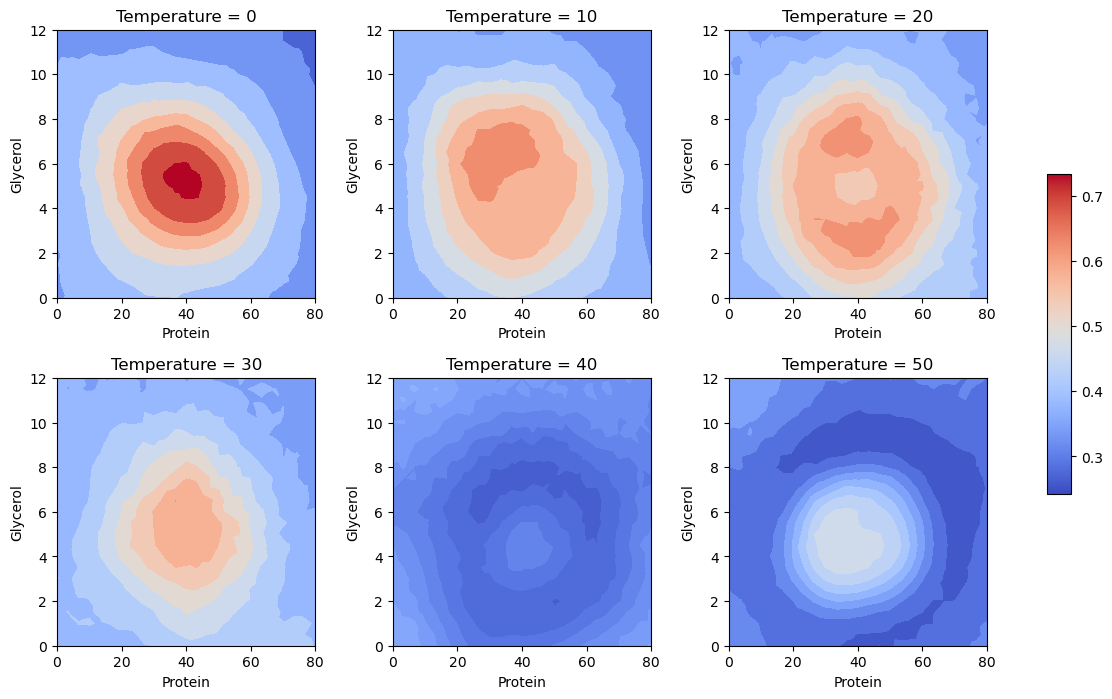

In [97]:
plot_value_slices(ds_result, "acqv_cost")

In [98]:
def plot_progress(ds):
    """Plot cost and entropy in 3D."""
    fig, axs  = plt.subplots(1,3, 
                             figsize=(4*3, 4), 
                             subplot_kw={"projection":'3d'},
                             )

    ax = axs[0]
    ax.scatter(
        ds["composition"].sel(component='protein').values,
        ds["composition"].sel(component='glycerol').values,
        ds["composition"].sel(component='temperature').values,
        c=ds.labels.values
    )
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 12)
    ax.set_zlim(0, 50)

    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = plt.get_cmap('coolwarm')
    ax = axs[1]
    mappable = ax.scatter(
        ds["composition_grid"].sel(component='protein').values,
        ds["composition_grid"].sel(component='glycerol').values,
        ds["composition_grid"].sel(component='temperature').values,
        c=ds['acqv_cost'].values,
        cmap = cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label('Cost of next sample')

    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    cmap = plt.get_cmap("coolwarm")
    ax = axs[2]
    mappable = ax.scatter(
        ds["composition_grid"].sel(component='protein').values,
        ds["composition_grid"].sel(component='glycerol').values,
        ds["composition_grid"].sel(component='temperature').values,
        c=ds['phase_y_prob'].values,
        cmap=cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label('Entropy')

    for ax in axs:
        ax.set_xlabel('Protein')
        ax.set_ylabel('Glycerol')
        ax.set_zlabel('Temperature', labelpad=-2)
    plt.tight_layout()

    return fig, axs

## Run AL

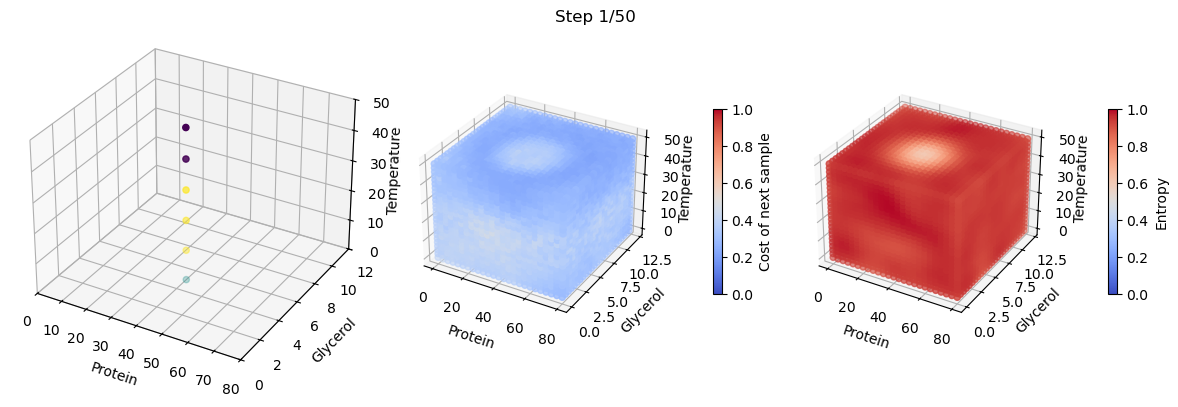

In [111]:
ds_running = ds_init.copy() 

n_steps = 50
for step in range(n_steps):
    ds_result = p.calculate(ds_running, disable_progress_bar=True)

    next_sample = ds_result['next_sample'].to_pandas().to_dict(orient='records')[0]
    ds_new = inst_client.simple_expose(next_sample)
    ds_new['phases'] = int(ds_new.attrs['labels'])
    
    ds_running = xr.concat([ds_running, ds_new], dim='sample')
    fig, axs = plot_progress(ds_result)
    fig.suptitle(f"Step {step+1}/{n_steps}")
    plt.show()
    break

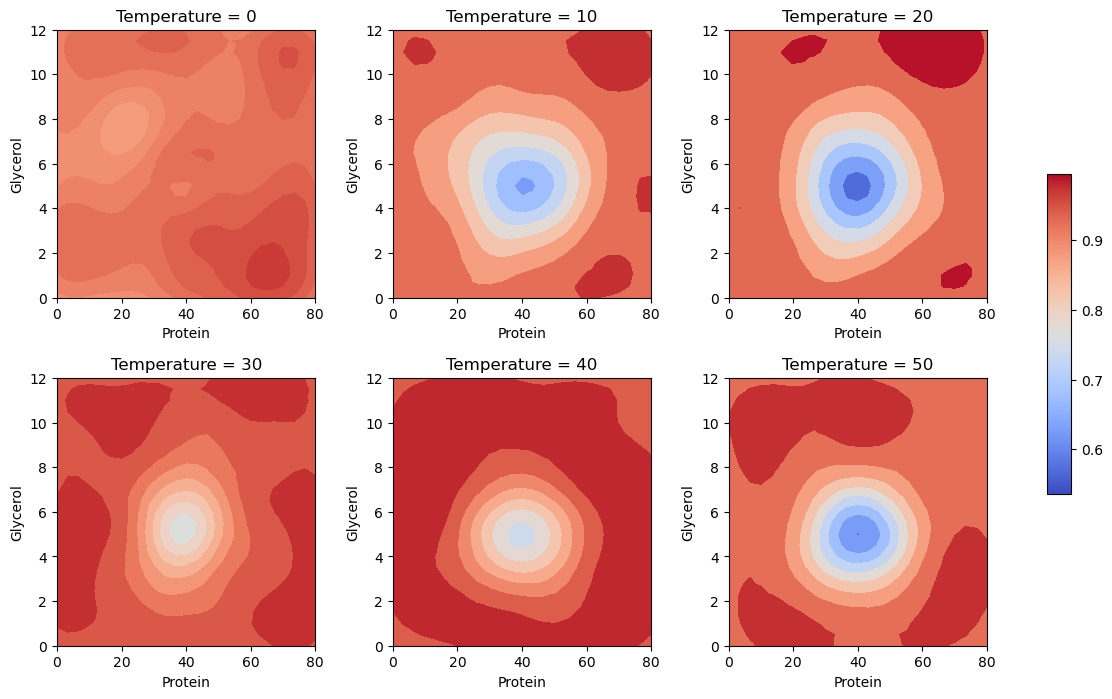

In [100]:
plot_value_slices(ds_result, "phase_entropy")

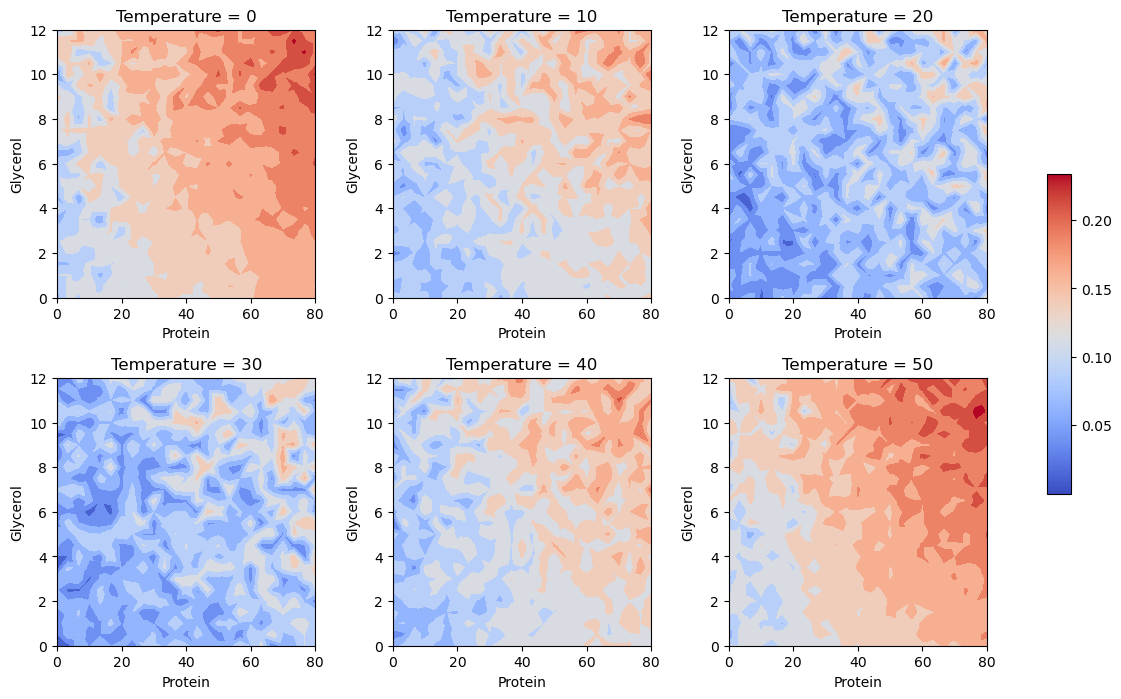

In [101]:
plot_value_slices(ds_result, "hierarchy_cost")

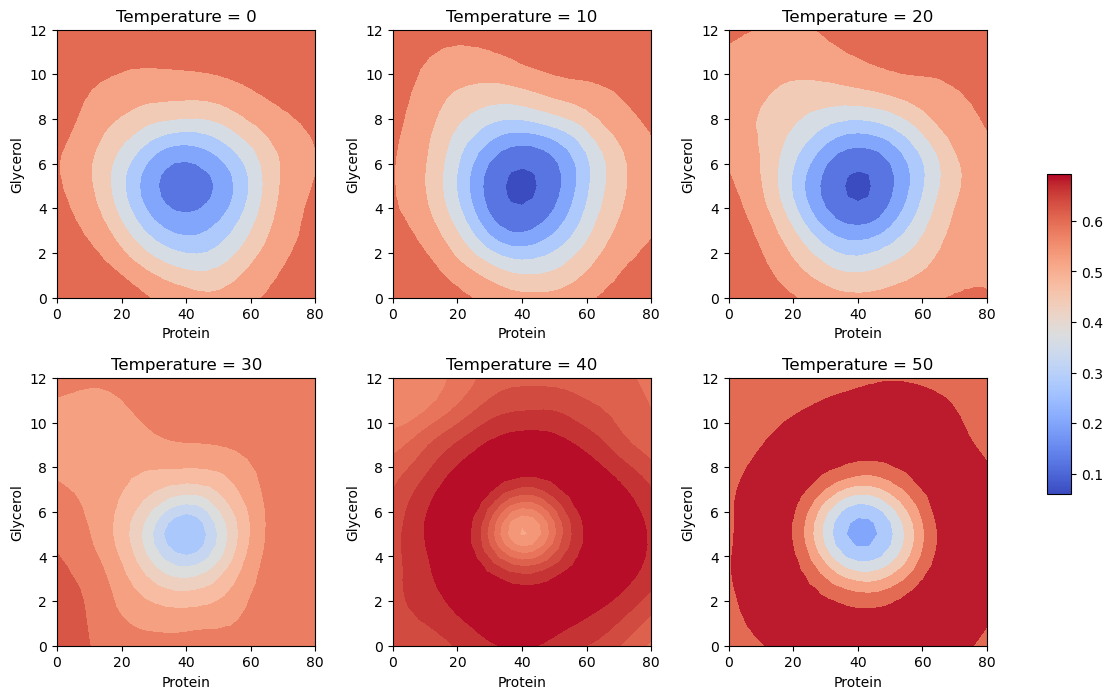

In [102]:
plot_value_slices(ds_result, "feasibility_y_prob")

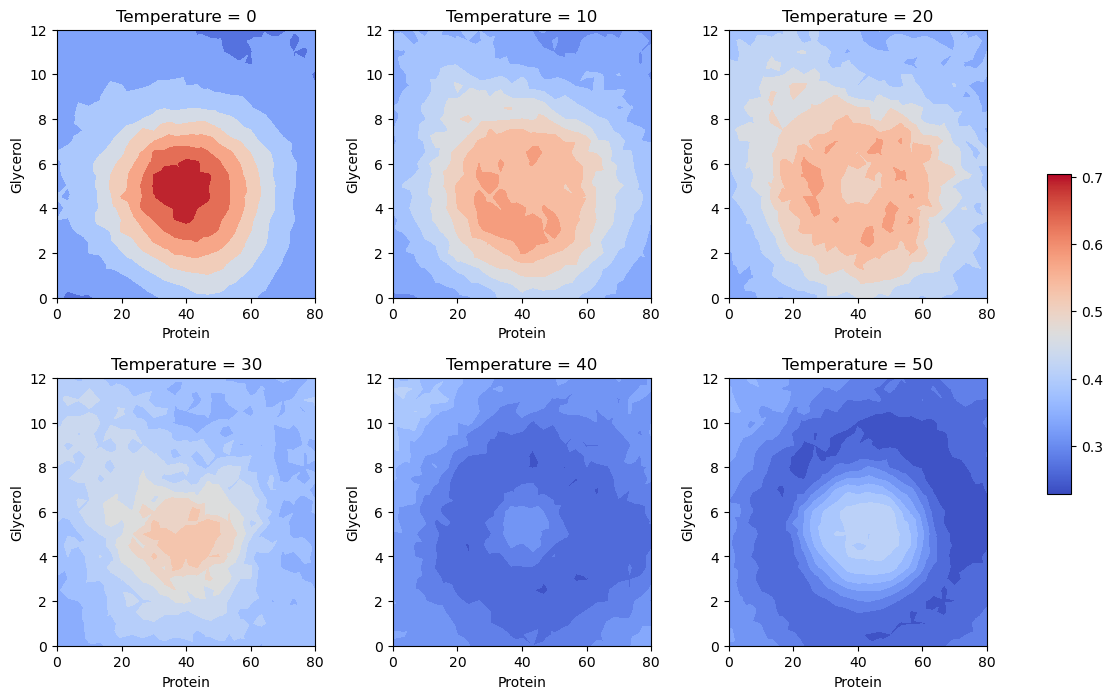

In [103]:
plot_value_slices(ds_result, "acqv_cost")

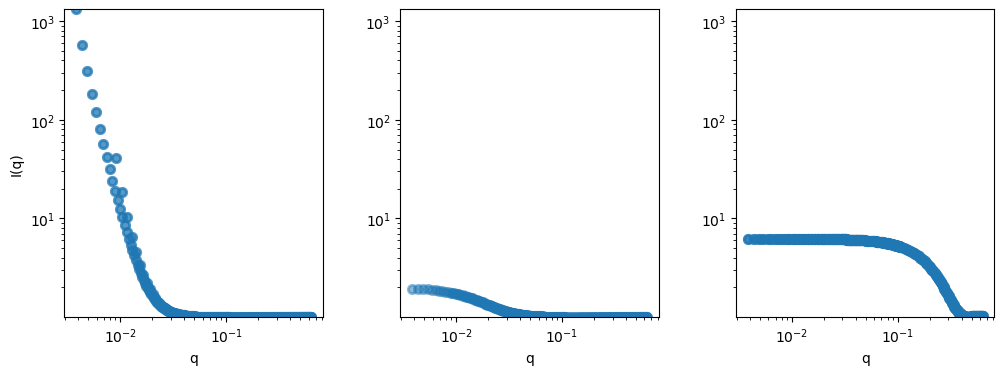

In [104]:
fig, axs = plt.subplots(1,3, figsize=(4*3, 4))
fig.subplots_adjust(wspace=0.3)
axs = axs.flatten()
q = ds_result.q.values 
Iq = ds_result.I.values
labels = ds_result.labels.values
for label in np.unique(labels):
    ax = axs[label]
    flags = labels == label
    Iq_current_phase = Iq[flags]
    for i in range(Iq_current_phase.shape[0]):
        ax.scatter(q, 
                  Iq_current_phase[i,:], 
                  color="tab:blue", 
                  lw=2.0, 
                  alpha=0.5
                )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("q")
    ax.set_ylim([Iq.min(), Iq.max()])
axs[0].set_ylabel("I(q)")
plt.show()